# Saturation Index — Calcite Precipitation Potential

This notebook demonstrates using the NR speciation engine to assess whether a
water is supersaturated with respect to calcite (CaCO₃).

The **saturation index** (SI) is defined as:

$$\text{SI} = \log_{10}\frac{\text{IAP}}{K_{\text{sp}}}
  = \log_{10}(a_{\text{Ca}^{2+}} \cdot a_{\text{CO}_3^{2-}}) - \log_{10} K_{\text{sp}}$$

| SI | Interpretation |
|---|---|
| SI > 0 | Supersaturated — calcite precipitation thermodynamically favoured |
| SI = 0 | Equilibrium with solid calcite |
| SI < 0 | Undersaturated — calcite would dissolve |

$K_{\text{sp}}(\text{calcite, 25 °C}) = 10^{-8.48}$

**Scope of this notebook:** the NR engine here is run in *dissolved-only* mode —
Ca²⁺ is modelled as a strong divalent cation that shifts the charge balance without
forming any precipitation reaction.  The engine returns the correct dissolved
speciation *as if precipitation were suppressed*; we then use those concentrations
to compute SI and confirm that SI > 0.  Full precipitation equilibria (active-set
NR with mineral mass as an unknown) are deferred to a future implementation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Run from inside the PyOMES repo")

sys.path.insert(0, str(_find_repo() / "models"))

from PyOMES.chemistry.common_species import (
    H2O, H_plus, OH_minus,
    CO2, HCO3_minus, CO3_2minus,
    NH3, NH4_plus, Na_plus, Cl_minus,
    H3PO4, H2PO4_minus, HPO4_2minus, PO4_3minus,
)
from PyOMES.reactions.equilibrium import EquilibriumReaction
from PyOMES.reactions.stoichiometry import StoichiometryEntry
from PyOMES.chemical_equilibrium.nr_engine import NRChemicalEquilibriumEngine

def _e(sp, coeff):
    return StoichiometryEntry(species=sp, phase="liquid", coefficient=coeff)

print("Imports OK")
from PyOMES.chemical_equilibrium.activity_models import DaviesActivityModel

davies = DaviesActivityModel()
Ksp_calcite = 10**(-8.48)   # calcite solubility product at 25 °C
print("Imports OK")


Imports OK
Imports OK


## 1  Carbonate chemistry declaration

Ca²⁺ participates in the charge balance only — it is a strong divalent cation
with no acid-base reactions in this model.  The dissolved carbonate speciation
is governed by the same three equilibria used in the single-component benchmarks.

| Reaction | log K | Role |
|---|---|---|
| H₂O ⇌ H⁺ + OH⁻ | −14.0 | water autoionisation |
| CO₂ + H₂O ⇌ HCO₃⁻ + H⁺ | −6.35 | first carbonate dissociation |
| HCO₃⁻ ⇌ CO₃²⁻ + H⁺ | −10.33 | second carbonate dissociation |

Ca²⁺ is passed to `solve()` via `strong_ions={"CT_Ca": ...}` with a charge of +2.

In [2]:
water = EquilibriumReaction(
    stoichiometry=[_e(H2O, -1), _e(H_plus, +1), _e(OH_minus, +1)],
    log_K=-14.0, label="water",
)
co2_first = EquilibriumReaction(
    stoichiometry=[_e(CO2, -1), _e(H2O, -1), _e(HCO3_minus, +1), _e(H_plus, +1)],
    log_K=-6.35, total_id="CO2", label="co2_first",
)
co2_second = EquilibriumReaction(
    stoichiometry=[_e(HCO3_minus, -1), _e(CO3_2minus, +1), _e(H_plus, +1)],
    log_K=-10.33, total_id="CO2", label="co2_second",
)

engine = NRChemicalEquilibriumEngine.from_reactions(
    [water, co2_first, co2_second], use_activity=True, activity_model="davies"
)
print("Masters:    ", engine.tableau.masters)
print("Secondaries:", [s.species_id for s in engine.tableau.secondaries])


Masters:     ['H+', 'CO2']
Secondaries: ['OH-', 'HCO3-', 'CO3--']


## 2  Hard-water speciation at a single point

A moderately hard process water with:

| Parameter | Value | Notes |
|---|---|---|
| CT_CO₂ | 10 mmol/L | total inorganic carbon (CO₂ + HCO₃⁻ + CO₃²⁻) |
| CT_Ca | 2 mmol/L | total calcium (treated as strong Ca²⁺) |
| CT_Na | 5 mmol/L | NaOH addition — raises pH by adding positive strong-ion charge |

The charge balance at these conditions requires a net alkalinity of
CT_Na + 2·CT_Ca = 9 mmol/L, supplied almost entirely by HCO₃⁻.  The remaining
carbonate sits as dissolved CO₂, fixing the pH near neutral–slightly basic.

In [3]:
T_K   = 298.15
CT_Ca = 0.002    # mol/L
CT_CO2 = 0.010   # mol/L
CT_Na  = 0.005   # mol/L

out = engine.solve(
    totals={"CO2": CT_CO2},
    strong_ions={"CT_Ca": CT_Ca, "CT_Na": CT_Na},
    T_K=T_K,
)

pH    = out.pH
c_CO2  = out.species_mol_L["CO2"]
c_HCO3 = out.species_mol_L["HCO3-"]
c_CO3  = out.species_mol_L["CO3--"]
I      = out.ionic_strength

print(f"pH               = {pH:.4f}")
print(f"[CO2]            = {c_CO2*1e3:.4f} mmol/L")
print(f"[HCO3-]          = {c_HCO3*1e3:.4f} mmol/L")
print(f"[CO3--]          = {c_CO3*1e6:.4f} µmol/L")
print(f"Ionic strength   = {I*1e3:.2f} mmol/L")
print(f"Charge residual  = {out.charge_residual:.2e}")


pH               = 7.2518
[CO2]            = 1.0105 mmol/L
[HCO3-]          = 8.9791 mmol/L
[CO3--]          = 10.3680 µmol/L
Ionic strength   = 11.01 mmol/L
Charge residual  = -2.30e-10


## 3  Saturation index calculation

### Without activity corrections (γ = 1)

$$\text{SI}_{\text{ideal}} = \log_{10}([\text{Ca}^{2+}]\cdot[\text{CO}_3^{2-}]) - \log_{10} K_{\text{sp}}$$

### With Davies activity corrections

$$\text{SI}_{\text{Davies}} = \log_{10}(\gamma_{\text{Ca}} \cdot [\text{Ca}^{2+}])
  + \log_{10}(\gamma_{\text{CO}_3} \cdot [\text{CO}_3^{2-}]) - \log_{10} K_{\text{sp}}$$

Activity coefficients are evaluated at the ionic strength returned by the solver.
Because Ca²⁺ and CO₃²⁻ both carry |z| = 2, the Davies equation gives the same
γ for both:

$$\log \gamma = -A(T)\cdot 4 \cdot \left(\frac{\sqrt{I}}{1+\sqrt{I}} - 0.3I\right)$$


In [4]:
# Activity coefficients for divalent ions at the solved ionic strength
gamma_z2 = davies.gamma(2, I, T_K=T_K)   # same for Ca²⁺ and CO₃²⁻ (|z|=2)

# Ion activity products
IAP_ideal  = CT_Ca * c_CO3
IAP_davies = (gamma_z2 * CT_Ca) * (gamma_z2 * c_CO3)

SI_ideal  = np.log10(IAP_ideal  / Ksp_calcite)
SI_davies = np.log10(IAP_davies / Ksp_calcite)

print(f"γ(z=±2) at I = {I*1e3:.2f} mmol/L  →  γ = {gamma_z2:.4f}")
print()
print(f"IAP (ideal)   = {IAP_ideal:.3e}  →  log₁₀(IAP) = {np.log10(IAP_ideal):.3f}")
print(f"IAP (Davies)  = {IAP_davies:.3e}  →  log₁₀(IAP) = {np.log10(IAP_davies):.3f}")
print(f"log₁₀(Ksp)              =  {np.log10(Ksp_calcite):.2f}")
print()
print(f"SI (ideal)   = {SI_ideal:+.4f}  {'> 0 → SUPERSATURATED' if SI_ideal > 0 else '< 0 → undersaturated'}")
print(f"SI (Davies)  = {SI_davies:+.4f}  {'> 0 → SUPERSATURATED' if SI_davies > 0 else '< 0 → undersaturated'}")


γ(z=±2) at I = 11.01 mmol/L  →  γ = 0.6493

IAP (ideal)   = 2.074e-08  →  log₁₀(IAP) = -7.683
IAP (Davies)  = 8.743e-09  →  log₁₀(IAP) = -8.058
log₁₀(Ksp)              =  -8.48

SI (ideal)   = +0.7967  > 0 → SUPERSATURATED
SI (Davies)  = +0.4217  > 0 → SUPERSATURATED


## 4  Saturation index vs pH — NaOH dosing

Increasing the NaOH dose (CT_Na) raises pH by adding positive charge to the
charge balance.  As pH rises:

- More carbonate is in the CO₃²⁻ form (α₂ increases steeply above pH 8)
- [CO₃²⁻] increases → IAP increases → SI rises

The plot below shows SI as a function of pH, achieved by sweeping CT_Na from 0
to 14 mmol/L.  The SI = 0 crossing marks the **minimum pH for calcite precipitation**
at these total concentrations.

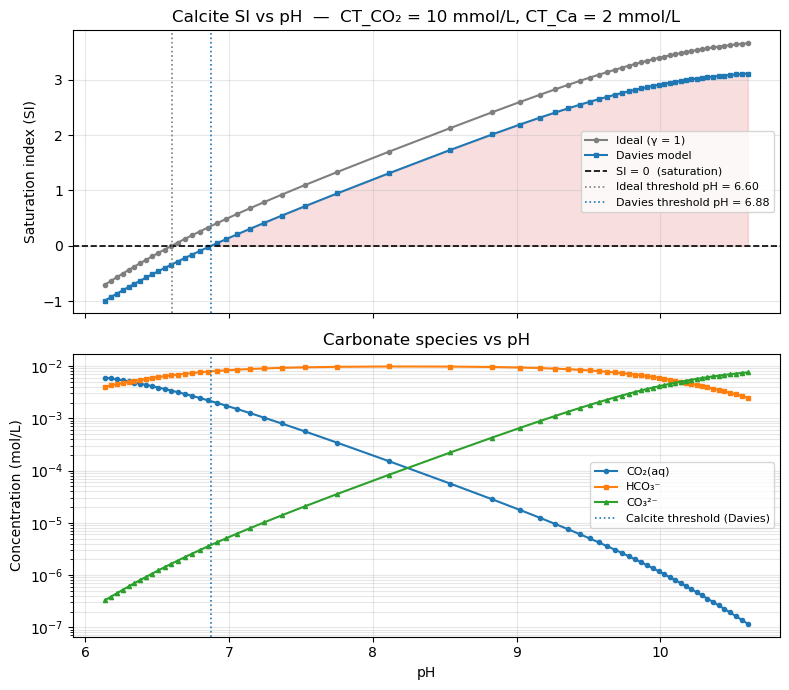


SI = 0 crossing (ideal):  pH = 6.601
SI = 0 crossing (Davies):  pH = 6.876


In [5]:
na_sweep  = np.linspace(0.0, 0.014, 60)
pH_sweep  = []
SI_i_sweep = []
SI_d_sweep = []

for na in na_sweep:
    o = engine.solve(
        totals={"CO2": CT_CO2},
        strong_ions={"CT_Ca": CT_Ca, "CT_Na": na},
        T_K=T_K,
    )
    g = davies.gamma(2, o.ionic_strength, T_K=T_K)
    iap_i = CT_Ca * o.species_mol_L["CO3--"]
    iap_d = (g * CT_Ca) * (g * o.species_mol_L["CO3--"])
    pH_sweep.append(o.pH)
    SI_i_sweep.append(np.log10(iap_i / Ksp_calcite))
    SI_d_sweep.append(np.log10(iap_d / Ksp_calcite))

pH_arr = np.array(pH_sweep)
SI_i   = np.array(SI_i_sweep)
SI_d   = np.array(SI_d_sweep)

# Find pH crossings (SI = 0)
def _crossing_pH(pH, SI):
    for k in range(len(SI)-1):
        if SI[k] <= 0 < SI[k+1]:
            # linear interpolation
            frac = -SI[k] / (SI[k+1] - SI[k])
            return pH[k] + frac*(pH[k+1]-pH[k])
    return None

pH_cross_i = _crossing_pH(pH_arr, SI_i)
pH_cross_d = _crossing_pH(pH_arr, SI_d)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(pH_arr, SI_i, "o-", ms=3, color="tab:gray",  label="Ideal (γ = 1)")
axes[0].plot(pH_arr, SI_d, "s-", ms=3, color="tab:blue",  label="Davies model")
axes[0].axhline(0, color="k", lw=1.2, ls="--", label="SI = 0  (saturation)")
if pH_cross_i:
    axes[0].axvline(pH_cross_i, color="tab:gray",  ls=":", lw=1.2,
                    label=f"Ideal threshold pH = {pH_cross_i:.2f}")
if pH_cross_d:
    axes[0].axvline(pH_cross_d, color="tab:blue", ls=":", lw=1.2,
                    label=f"Davies threshold pH = {pH_cross_d:.2f}")
axes[0].set_ylabel("Saturation index (SI)")
axes[0].set_title(f"Calcite SI vs pH  —  CT_CO₂ = {CT_CO2*1e3:.0f} mmol/L, CT_Ca = {CT_Ca*1e3:.0f} mmol/L")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(pH_arr, SI_d, 0, where=(SI_d > 0),
                      color="tab:red", alpha=0.15, label="supersaturated region")

# Carbonate species
c_CO2_sw  = [engine.solve(totals={"CO2": CT_CO2},
                           strong_ions={"CT_Ca": CT_Ca, "CT_Na": na}, T_K=T_K).species_mol_L["CO2"]
              for na in na_sweep]
c_HCO3_sw = [engine.solve(totals={"CO2": CT_CO2},
                           strong_ions={"CT_Ca": CT_Ca, "CT_Na": na}, T_K=T_K).species_mol_L["HCO3-"]
              for na in na_sweep]
c_CO3_sw  = [engine.solve(totals={"CO2": CT_CO2},
                           strong_ions={"CT_Ca": CT_Ca, "CT_Na": na}, T_K=T_K).species_mol_L["CO3--"]
              for na in na_sweep]

axes[1].semilogy(pH_arr, c_CO2_sw,  "o-", ms=3, color="tab:blue",   label="CO₂(aq)")
axes[1].semilogy(pH_arr, c_HCO3_sw, "s-", ms=3, color="tab:orange", label="HCO₃⁻")
axes[1].semilogy(pH_arr, c_CO3_sw,  "^-", ms=3, color="tab:green",  label="CO₃²⁻")
if pH_cross_d:
    axes[1].axvline(pH_cross_d, color="tab:blue", ls=":", lw=1.2,
                    label=f"Calcite threshold (Davies)")
axes[1].set_xlabel("pH")
axes[1].set_ylabel("Concentration (mol/L)")
axes[1].set_title("Carbonate species vs pH")
axes[1].legend(fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSI = 0 crossing (ideal):  pH = {pH_cross_i:.3f}" if pH_cross_i else "")
print(f"SI = 0 crossing (Davies):  pH = {pH_cross_d:.3f}" if pH_cross_d else "")


## 5  Precipitation risk map — CT_Ca vs CT_CO₂

For a fixed pH (here pH 8.0, imposed by choosing CT_Na to hit the target), the
saturation index depends on how much calcium and carbonate are dissolved.
The map below shows where combinations of (CT_Ca, CT_CO₂) cross from
undersaturated (SI < 0) to supersaturated (SI > 0).

This is the kind of assessment done in reverse-osmosis concentrate management,
cooling-tower blowdown design, and lime-softening process control.

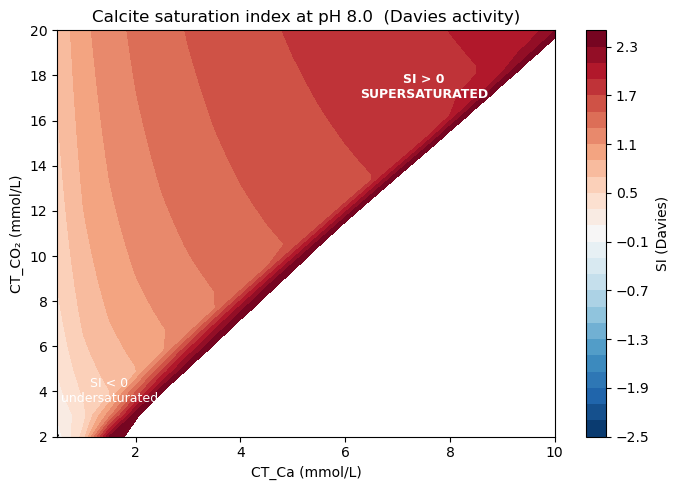

In [6]:
from itertools import product as iproduct

Ka1 = 10**(-6.35)
Ka2 = 10**(-10.33)
Kw  = 10**(-14.0)

def na_for_pH(target_pH, CT_CO2_, CT_Ca_):
    """Analytical estimate of CT_Na needed to hit target_pH."""
    H  = 10**(-target_pH)
    OH = Kw / H
    D  = H**2 + Ka1*H + Ka1*Ka2
    HCO3 = Ka1*H/D * CT_CO2_
    CO3  = Ka1*Ka2/D * CT_CO2_
    # charge balance: H + Na + 2*Ca = OH + HCO3 + 2*CO3
    na = (OH + HCO3 + 2*CO3) - (H + 2*CT_Ca_)
    return max(na, 0.0)

Ca_vals  = np.linspace(0.0005, 0.010, 20)    # 0.5–10 mmol/L
CO2_vals = np.linspace(0.002,  0.020, 20)    # 2–20 mmol/L
target_pH = 8.0

SI_grid = np.zeros((len(CO2_vals), len(Ca_vals)))

for i, CT_CO2_ in enumerate(CO2_vals):
    for j, CT_Ca_ in enumerate(Ca_vals):
        na = na_for_pH(target_pH, CT_CO2_, CT_Ca_)
        o  = engine.solve(
            totals={"CO2": CT_CO2_},
            strong_ions={"CT_Ca": CT_Ca_, "CT_Na": na},
            T_K=T_K,
        )
        g = davies.gamma(2, o.ionic_strength, T_K=T_K)
        iap = (g * CT_Ca_) * (g * o.species_mol_L["CO3--"])
        SI_grid[i, j] = np.log10(iap / Ksp_calcite)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(Ca_vals*1e3, CO2_vals*1e3, SI_grid,
                 levels=np.linspace(-2.5, 2.5, 26), cmap="RdBu_r")
cb = fig.colorbar(cs, ax=ax, label="SI (Davies)")
ax.contour(Ca_vals*1e3, CO2_vals*1e3, SI_grid, levels=[0],
           colors="black", linewidths=2, linestyles="--")
ax.set_xlabel("CT_Ca (mmol/L)")
ax.set_ylabel("CT_CO₂ (mmol/L)")
ax.set_title(f"Calcite saturation index at pH {target_pH:.1f}  (Davies activity)")
ax.text(7.5, 17.5, "SI > 0\nSUPERSATURATED", color="white", fontsize=9,
        ha="center", va="center", fontweight="bold")
ax.text(1.5, 4.0, "SI < 0\nundersaturated", color="white", fontsize=9,
        ha="center", va="center")
plt.tight_layout()
plt.show()


## 6  Scope and next steps

This notebook uses the NR engine in **dissolved-only** mode.  When SI > 0:

- The engine returns the *supersaturated* dissolved composition (as if no solid
  were present).
- The true equilibrium has less dissolved Ca²⁺ and CO₃²⁻, because some CaCO₃
  has precipitated to bring IAP = Ksp.

The dissolved-only solve is sufficient for:

1. **Scaling risk assessment** — SI > 0 flags combinations of (CT_Ca, CT_CO₂, pH)
   that are prone to pipe / membrane fouling without needing to know how much
   solid forms.
2. **Operating envelope design** — the SI = 0 contour defines the maximum safe
   calcium or alkalinity loading at a given pH.

A full **precipitation equilibrium** solver — where mineral amount is an
additional unknown and IAP = Ksp replaces the dissolved mass balance for Ca²⁺ —
requires an active-set Newton-Raphson outer loop and is deferred to a future
implementation.